# Log Stellar Mass Result Comparison

Load successful `run_manifest_fit.py` JSON results from a results folder and compare recovered log stellar mass against the Chimera truth value. Edit `RESULTS_DIR` in the first code cell to point at another run's `results/` folder.

In [6]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

RESULTS_DIR = Path("hpc_outputs/loglbol_mass_retrieval/manual_single_013549_ns/results")
JSON_PATTERN = "*.json"
LOGM_RANGE = (7.6, 9.1)

In [7]:
def _as_float(payload, key):
    value = payload.get(key)
    if value is None:
        return math.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


def load_result_rows(results_dir, pattern=JSON_PATTERN):
    results_dir = Path(results_dir).expanduser()
    if not results_dir.exists():
        raise FileNotFoundError(f"Results folder does not exist: {results_dir}")

    rows = []
    skipped = []
    for path in sorted(results_dir.glob(pattern)):
        try:
            payload = json.loads(path.read_text())
        except Exception as exc:
            skipped.append((path.name, f"could not read JSON: {exc}"))
            continue

        if payload.get("status") != "success":
            skipped.append((path.name, f"status={payload.get('status')!r}"))
            continue

        truth = _as_float(payload, "log_stellar_mass_truth")
        recovered = _as_float(payload, "recovered_logm")
        if not (np.isfinite(truth) and np.isfinite(recovered)):
            skipped.append((path.name, "missing finite truth or recovered_logm"))
            continue

        rows.append(
            {
                "path": path,
                "fit_index": payload.get("fit_index"),
                "object_id": payload.get("object_id", ""),
                "COSMOS_ID0": payload.get("COSMOS_ID0", ""),
                "truth": truth,
                "recovered": recovered,
                "p16": _as_float(payload, "logm16"),
                "p84": _as_float(payload, "logm84"),
                "residual": recovered - truth,
            }
        )

    rows.sort(key=lambda row: (row["fit_index"] is None, row["fit_index"], row["object_id"]))
    return rows, skipped


rows, skipped = load_result_rows(RESULTS_DIR)
print(f"Loaded {len(rows)} successful result(s) from {RESULTS_DIR.resolve()}")
if skipped:
    print(f"Skipped {len(skipped)} file(s). First skipped entries:")
    for name, reason in skipped[:10]:
        print(f"  {name}: {reason}")
if not rows:
    raise RuntimeError("No successful result JSON files with log stellar mass values were found.")

Loaded 1 successful result(s) from /home/dutra/dev/nicholas/hpc_outputs/loglbol_mass_retrieval/manual_single_013549_ns/results


In [8]:
truth = np.array([row["truth"] for row in rows], dtype=float)
recovered = np.array([row["recovered"] for row in rows], dtype=float)
p16 = np.array([row["p16"] for row in rows], dtype=float)
p84 = np.array([row["p84"] for row in rows], dtype=float)
residual = recovered - truth

summary = {
    "n": len(rows),
    "median residual": float(np.median(residual)),
    "mean residual": float(np.mean(residual)),
    "scatter std": float(np.std(residual)),
    "MAE": float(np.mean(np.abs(residual))),
}

display(Markdown("\n".join([
    "## Summary",
    "",
    *[f"- **{key}**: {value:.4g}" if isinstance(value, float) else f"- **{key}**: {value}" for key, value in summary.items()],
])))

table_rows = [
    "| fit_index | COSMOS_ID0 | object_id | truth | recovered | residual |",
    "|---:|---:|---|---:|---:|---:|",
]
for row in rows[:25]:
    table_rows.append(
        f"| {row['fit_index']} | {row['COSMOS_ID0']} | `{row['object_id']}` | "
        f"{row['truth']:.4f} | {row['recovered']:.4f} | {row['residual']:+.4f} |"
    )
if len(rows) > 25:
    table_rows.append(f"| ... | ... | showing first 25 of {len(rows)} rows | ... | ... | ... |")
display(Markdown("\n".join(table_rows)))

## Summary

- **n**: 1
- **median residual**: 0.1854
- **mean residual**: 0.1854
- **scatter std**: 0
- **MAE**: 0.1854

| fit_index | COSMOS_ID0 | object_id | truth | recovered | residual |
|---:|---:|---|---:|---:|---:|
| 0 | 243632 | `013549.53+241149.7_243632_0.0001` | 8.3345 | 8.5198 | +0.1854 |

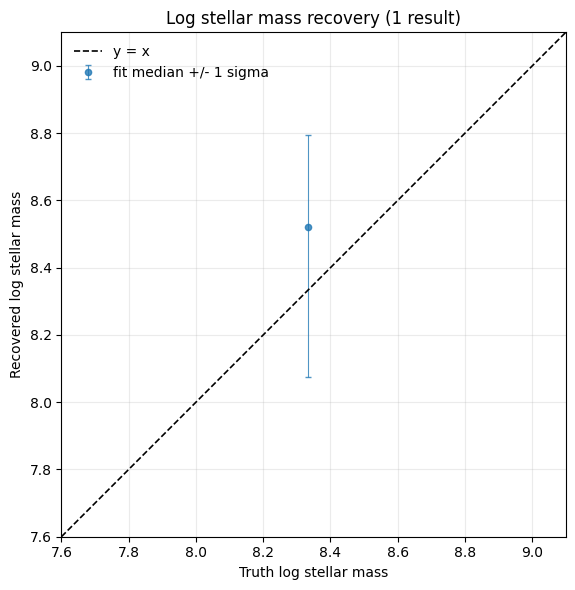

In [9]:
err_lo = recovered - p16
err_hi = p84 - recovered
has_uncertainty = np.all(np.isfinite(err_lo)) and np.all(np.isfinite(err_hi)) and np.all(err_lo >= 0) and np.all(err_hi >= 0)

fig, ax = plt.subplots(figsize=(6.4, 6.0))
if has_uncertainty:
    ax.errorbar(
        truth,
        recovered,
        yerr=np.vstack([err_lo, err_hi]),
        fmt="o",
        ms=4.5,
        alpha=0.78,
        capsize=2,
        elinewidth=0.8,
        label="fit median +/- 1 sigma",
    )
else:
    ax.scatter(truth, recovered, s=26, alpha=0.78, label="fit median")

lo, hi = LOGM_RANGE
ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="y = x")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Truth log stellar mass")
ax.set_ylabel("Recovered log stellar mass")
ax.set_title(f"Log stellar mass recovery ({len(rows)} result{'s' if len(rows) != 1 else ''})")
ax.grid(alpha=0.25)
ax.legend(loc="best", frameon=False)
fig.tight_layout()
plt.show()

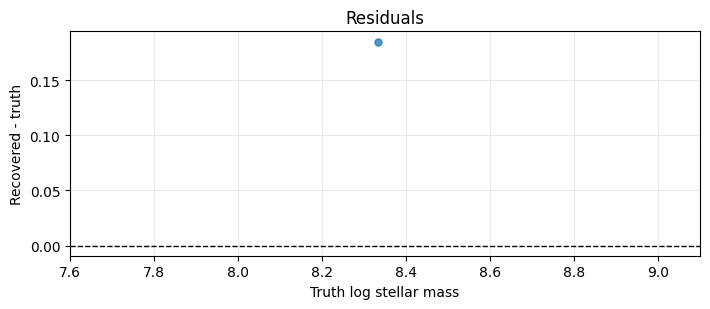

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.axhline(0.0, color="k", ls="--", lw=1.0)
ax.scatter(truth, residual, s=26, alpha=0.78)
ax.set_xlim(*LOGM_RANGE)
ax.set_xlabel("Truth log stellar mass")
ax.set_ylabel("Recovered - truth")
ax.set_title("Residuals")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()